In [39]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os

In [40]:
class ImageClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

In [41]:
model_path = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\best_classifier 1.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImageClassifier(num_classes=6)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()    

ImageClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [42]:
class MyCustomDataset(Dataset):
    def __init__(self, data_root, transform=None):
        self.data_root = data_root
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self._load_samples()

    def _load_samples(self):
        classes = sorted(os.listdir(self.data_root))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(self.data_root, cls)
            for file in os.listdir(class_dir):
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.samples.append(
                        (os.path.join(class_dir, file), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [43]:
# aug_transform = transforms.Compose([
#     transforms.Resize((256,256)),
#     transforms.RandomResizedCrop(224),
#     transforms.RandomHorizontalFlip(),
#     transforms.RandomRotation(15),
#     transforms.ColorJitter(0.3,0.3,0.3,0.1),
#     transforms.ToTensor(),
#     transforms.Normalize([0.485,0.456,0.406],
#                          [0.229,0.224,0.225])
#])


aug_transform = transforms.Compose([
    transforms.Resize((256, 256)),

    #  Core augmentation
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),

    #  Mild rotation (avoid distortion)
    transforms.RandomRotation(degrees=10),

    #  Slight movement
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)  # small shift only
    ),

    #  Light color changes
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    #  Convert to tensor
    transforms.ToTensor(),

    #  Normalize (important for ResNet)
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
data_root = "Cropped_data"

#val_dataset_clean = MyCustomDataset(data_root, transform=val_transform)
val_dataset_aug   = MyCustomDataset(data_root, transform=aug_transform)

In [29]:
#val_loader_clean = DataLoader(val_dataset_clean, batch_size=16, shuffle=False)
val_loader_aug   = DataLoader(val_dataset_aug, batch_size=16, shuffle=False)

In [30]:
def evaluate(model, loader):
    preds = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(pred)
            labels_all.extend(labels.numpy())

    return confusion_matrix(labels_all, preds)

In [31]:
#cm_clean = evaluate(model, val_loader_clean)
cm_aug   = evaluate(model, val_loader_aug)

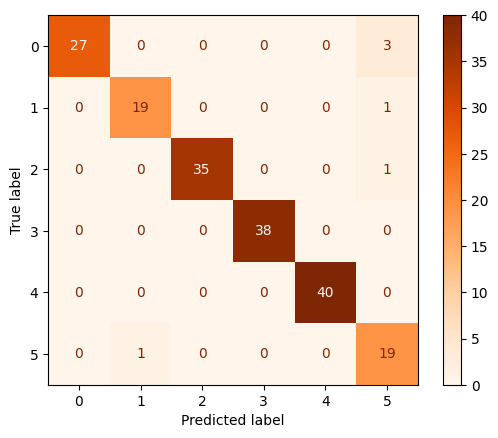

In [41]:
# fig, axes = plt.plots(1, figsize=(6,5))

# ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], cmap="Blues")
# axes[0].set_title("Clean Validation")

ConfusionMatrixDisplay(cm_aug).plot(cmap="Oranges")


plt.show()

In [60]:
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [62]:

data_root="augmentation_data"
val_dataset_clean = MyCustomDataset(data_root, transform=val_transform)

In [63]:

val_loader_clean = DataLoader(val_dataset_clean, batch_size=16, shuffle=False)

In [ ]:

cm_clean = evaluate(model, val_loader_clean)

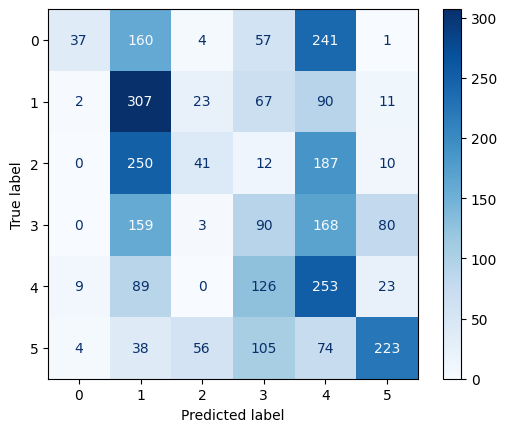

In [65]:

ConfusionMatrixDisplay(cm_clean).plot(cmap="Blues")

plt.show()

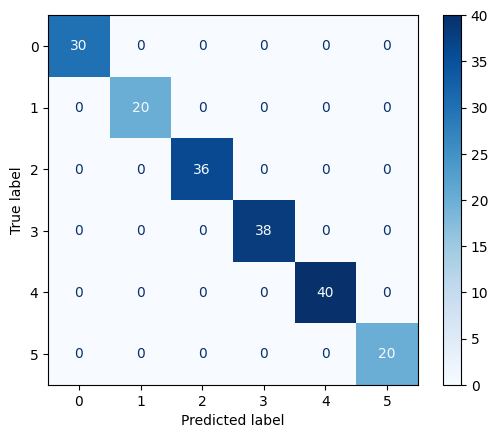

In [51]:

ConfusionMatrixDisplay(cm_clean).plot(cmap="Blues")

plt.show()

In [25]:
import os
import random
from PIL import Image
from torchvision import transforms

# 1️⃣ Define paths
data_root = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\Cropped_data"
save_root = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\augmentation_data"

# 2️⃣ Target count
target_count = 500

# 3️⃣ Define augmentation
augment = transforms.Compose([
    transforms.Resize((256, 256)),
    #  Core augmentation
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    #  Mild rotation (avoid distortion)
    transforms.RandomRotation(degrees=10),
    #  Slight movement
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05)  # small shift only
    ),
   
   
])

# 4️⃣ Create save root folder
os.makedirs(save_root, exist_ok=True)

# 5️⃣ Loop through each class
for cls in os.listdir(data_root):

    class_dir = os.path.join(data_root, cls)

    # 6️⃣ Validate folder
    if not os.path.isdir(class_dir):
        continue

    # 7️⃣ Create same class structure in save_root
    save_class_dir = os.path.join(save_root, cls)
    os.makedirs(save_class_dir, exist_ok=True)

    # 8️⃣ Get original images
    original_images = [
        img for img in os.listdir(class_dir)
        if img.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    # 9️⃣ Copy original images to save_root
    for img_name in original_images:
        src_path = os.path.join(class_dir, img_name)
        dst_path = os.path.join(save_class_dir, img_name)

        if not os.path.exists(dst_path):
            img = Image.open(src_path).convert("RGB")
            img.save(dst_path)

    # 🔟 Check existing images in save_root
    saved_images = [
        img for img in os.listdir(save_class_dir)
        if img.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    current_count = len(saved_images)

    print(f"\nClass: {cls}")
    print(f"Existing images before augmentation: {current_count}")

    # 1️⃣1️⃣ If already 500 → skip
    if current_count >= target_count:
        print("Already reached target, skipping...")
        continue

    # 1️⃣2️⃣ Augmentation loop
    while current_count < target_count:

        # pick random image from original class
        img_name = random.choice(original_images)
        img_path = os.path.join(class_dir, img_name)

        img = Image.open(img_path).convert("RGB")

        # apply augmentation
        aug_img = augment(img)
       


        # save augmented image
        save_name = f"aug_{current_count}_{img_name}"
        save_path = os.path.join(save_class_dir, save_name)

        aug_img.save(save_path)

        current_count += 1

    print(f"Completed {cls} → {current_count} images")

print("\nAll classes processed. Augmentation complete.")


Class: 05-19   # 67
Existing images before augmentation: 30
Completed 05-19   # 67 → 500 images

Class: 108-117   # 78
Existing images before augmentation: 20
Completed 108-117   # 78 → 500 images

Class: 20-37   # 57
Existing images before augmentation: 36
Completed 20-37   # 57 → 500 images

Class: 58-77   610
Existing images before augmentation: 38
Completed 58-77   610 → 500 images

Class: 78-97   # 89
Existing images before augmentation: 40
Completed 78-97   # 89 → 500 images

Class: 98-107   # 57
Existing images before augmentation: 20
Completed 98-107   # 57 → 500 images

All classes processed. Augmentation complete.


In [66]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os


In [67]:
class ImageClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

In [68]:
model_path = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\best_classifier 1.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImageClassifier(num_classes=6)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()    

ImageClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

In [69]:
class MyCustomDataset(Dataset):
    def __init__(self, data_root, transform=None):
        self.data_root = data_root
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self._load_samples()

    def _load_samples(self):
        classes = sorted(os.listdir(self.data_root))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(self.data_root, cls)
            for file in os.listdir(class_dir):
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.samples.append(
                        (os.path.join(class_dir, file), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [70]:
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [71]:
def evaluate(model, loader):
    preds = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(pred)
            labels_all.extend(labels.numpy())

    return confusion_matrix(labels_all, preds)

In [72]:
data_root="augmentation_data"
val_dataset_clean = MyCustomDataset(data_root, transform=val_transform)

In [73]:
val_loader_clean = DataLoader(val_dataset_clean, batch_size=16, shuffle=False)

In [74]:
cm_clean = evaluate(model, val_loader_clean)

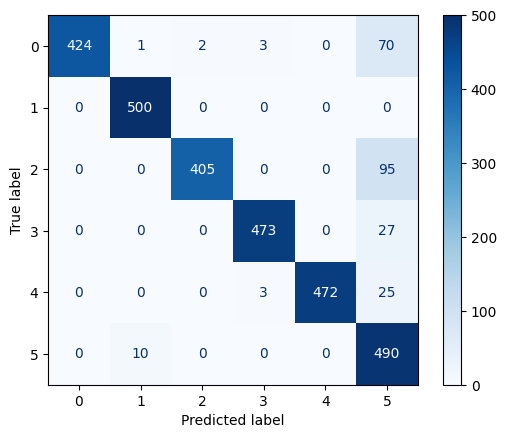

In [75]:
ConfusionMatrixDisplay(cm_clean).plot(cmap="Blues")


plt.show()

Prediction: 58-77   610


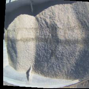

In [76]:
model_path = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\best_classifier 1.pt"
 
loaded_model = ImageClassifier(num_classes=6)
 
loaded_model.load_state_dict(torch.load(model_path,map_location="cpu"))
 
 
from PIL import Image
 
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
 
transform = transforms.Compose([
    transforms.Resize((225, 225)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
dataset = MyCustomDataset(
    data_root="augmentation_data",
    transform=transform
)
 
image_path = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\augmentation_data\58-77   610\aug_51_20.jpg"
 
loaded_model.eval()

 
img = Image.open(image_path)
 
with torch.no_grad():
    pred = loaded_model(transform(img).unsqueeze(0))
predicted_clss = list(dataset.class_to_idx)[np.argmax(pred.numpy())]
print(F"Prediction: {predicted_clss}")
img.resize((int(img.size[0]*0.4), int(img.size[1]*0.4)))
 

In [54]:
import os
import random
from PIL import Image
from torchvision import transforms

# 1️⃣ Define paths
data_root = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\Cropped_data"
save_root = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\augmentation_data1"

# 2️⃣ Target count
target_count = 500

# 3️⃣ Define augmentation
augment = transforms.Compose([
    transforms.Resize((256, 256)),
   
    transforms.RandomHorizontalFlip(p=0.5),
    #  Mild rotation (avoid distortion)
    transforms.RandomRotation(degrees=10),
    #  Slight movement
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03)  # small shift only
    ),
   
   
])

# 4️⃣ Create save root folder
os.makedirs(save_root, exist_ok=True)

# 5️⃣ Loop through each class
for cls in os.listdir(data_root):

    class_dir = os.path.join(data_root, cls)

    # 6️⃣ Validate folder
    if not os.path.isdir(class_dir):
        continue

    # 7️⃣ Create same class structure in save_root
    save_class_dir = os.path.join(save_root, cls)
    os.makedirs(save_class_dir, exist_ok=True)

    # 8️⃣ Get original images
    original_images = [
        img for img in os.listdir(class_dir)
        if img.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    # 9️⃣ Copy original images to save_root
    for img_name in original_images:
        src_path = os.path.join(class_dir, img_name)
        dst_path = os.path.join(save_class_dir, img_name)

        if not os.path.exists(dst_path):
            img = Image.open(src_path).convert("RGB")
            img.save(dst_path)

    # 🔟 Check existing images in save_root
    saved_images = [
        img for img in os.listdir(save_class_dir)
        if img.lower().endswith(('.jpg', '.png', '.jpeg'))
    ]

    current_count = len(saved_images)

    print(f"\nClass: {cls}")
    print(f"Existing images before augmentation: {current_count}")

    # 1️⃣1️⃣ If already 500 → skip
    if current_count >= target_count:
        print("Already reached target, skipping...")
        continue

    # 1️⃣2️⃣ Augmentation loop
    while current_count < target_count:

        # pick random image from original class
        img_name = random.choice(original_images)
        img_path = os.path.join(class_dir, img_name)

        img = Image.open(img_path).convert("RGB")

        # apply augmentation
        aug_img = augment(img)
       


        # save augmented image
        save_name = f"aug_{current_count}_{img_name}"
        save_path = os.path.join(save_class_dir, save_name)

        aug_img.save(save_path)

        current_count += 1

    print(f"Completed {cls} → {current_count} images")

print("\nAll classes processed. Augmentation complete.")


Class: 05-19   # 67
Existing images before augmentation: 30
Completed 05-19   # 67 → 500 images

Class: 108-117   # 78
Existing images before augmentation: 20
Completed 108-117   # 78 → 500 images

Class: 20-37   # 57
Existing images before augmentation: 36
Completed 20-37   # 57 → 500 images

Class: 58-77   610
Existing images before augmentation: 38
Completed 58-77   610 → 500 images

Class: 78-97   # 89
Existing images before augmentation: 40
Completed 78-97   # 89 → 500 images

Class: 98-107   # 57
Existing images before augmentation: 20
Completed 98-107   # 57 → 500 images

All classes processed. Augmentation complete.


In [80]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import os
class ImageClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.resnet18(weights=None)
        self.feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(self.feature_dim, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)
model_path = r"C:\Users\T074\git clone\project\Deep Learning\YOLO\yolo calssification\best_classifier 1.pt"

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ImageClassifier(num_classes=6)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()  
class MyCustomDataset(Dataset):
    def __init__(self, data_root, transform=None):
        self.data_root = data_root
        self.transform = transform
        self.samples = []
        self.class_to_idx = {}
        self._load_samples()

    def _load_samples(self):
        classes = sorted(os.listdir(self.data_root))
        self.class_to_idx = {cls: i for i, cls in enumerate(classes)}

        for cls in classes:
            class_dir = os.path.join(self.data_root, cls)
            for file in os.listdir(class_dir):
                if file.lower().endswith(('.jpg', '.png', '.jpeg')):
                    self.samples.append(
                        (os.path.join(class_dir, file), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])
def evaluate(model, loader):
    preds = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(pred)
            labels_all.extend(labels.numpy())

    return confusion_matrix(labels_all, preds)

In [81]:
data_root="augmentation_data1"
val_dataset_clean = MyCustomDataset(data_root, transform=val_transform)
val_loader_clean = DataLoader(val_dataset_clean, batch_size=16, shuffle=False)
cm_clean = evaluate(model, val_loader_clean)

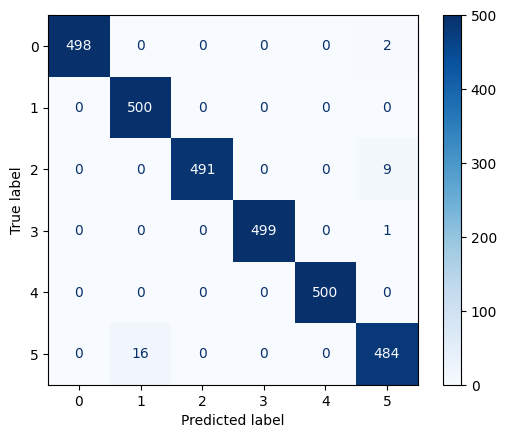

In [82]:
#after removing crop because data already crop
ConfusionMatrixDisplay(cm_clean).plot(cmap="Blues")


plt.show()